In [ ]:
# Proyecto Final: Accesibilidad a servicios de salud en la provincia de Huancayo

## Introducción
#Este proyecto analiza la distribución espacial de los establecimientos de salud en la provincia de Huancayo,
#combinando datos oficiales y datos complementarios obtenidos desde OpenStreetMap. El objetivo es evaluar la
#cobertura territorial de los servicios de salud mediante técnicas de análisis geoespacial.

## Objetivo
#Identificar patrones de distribución de los establecimientos de salud, medir la cobertura espacial y
#detectar zonas con menor acceso a estos servicios en los distritos de la provincia de Huancayo.

In [ ]:
#cagando las librerias
#FASE 1
import pandas as pd
import geopandas as gpd
import unicodedata #para quitar tildes
from shapely.geometry import Point
import matplotlib.pyplot as plt
!pip install contextily
import contextily as ctx


## Fase 1: Preparación y limpieza de datos

En esta fase se cargaron y organizaron las bases de datos necesarias para el análisis. Se utilizaron fuentes oficiales y complementarias. Los límites distritales y los datos de población corresponden a la provincia de Huancayo, mientras que la información de establecimientos de salud proviene de RENIPRESS datos abiertos de Perù, INEI Y los limites distritales de huancayo de igual manera de datos abiertos.

También se verificó el sistema de referencia espacial de las capas y se realizó la reproyección a un CRS indicado

In [ ]:
inei="/content/poblacion_huancayo_2020.xlsx"
poblacion=pd.read_excel(inei)
poblacion.head()

,ubigeo,distrito,habitantes,linck
0,120101,HUANCAYO,124294,https://www.inei.gob.pe/media/MenuRecursivo/pu...
1,120104,CARHUACALLANGA,468,https://www.inei.gob.pe/media/MenuRecursivo/pu...
2,120105,CHACAPAMPA,941,https://www.inei.gob.pe/media/MenuRecursivo/pu...
3,120106,CHICCHE,687,https://www.inei.gob.pe/media/MenuRecursivo/pu...
4,120107,CHILCA,100252,https://www.inei.gob.pe/media/MenuRecursivo/pu...


In [ ]:
poblacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ubigeo      28 non-null     int64 
 1   distrito    28 non-null     object
 2   habitantes  28 non-null     int64 
 3   linck       28 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.0+ KB


In [ ]:
poblacion_limpia = poblacion.copy()
# Eliminar columna que no usaremos
poblacion_limpia = poblacion_limpia.drop(columns=['linck'])
poblacion_limpia.head()

,ubigeo,distrito,habitantes
0,120101,HUANCAYO,124294
1,120104,CARHUACALLANGA,468
2,120105,CHACAPAMPA,941
3,120106,CHICCHE,687
4,120107,CHILCA,100252


In [ ]:
def quitar_tildes(texto):
    if isinstance(texto, str): #Si una celda tiene un número o está vacía, no podemos quitarle tildes
        return ''.join(
            c for c in unicodedata.normalize('NFD', texto) #Separa cada letra de su tilde
            if unicodedata.category(c) != 'Mn'  #Identifica cuáles son tildes
        )
    return texto

In [ ]:
# Aplicar solo a población
poblacion_limpia['distrito'] = poblacion_limpia['distrito'].apply(quitar_tildes) #Pandas recorre fila por fila automáticamente

# Verificando
print(poblacion_limpia['distrito'].unique())

['HUANCAYO' 'CARHUACALLANGA' 'CHACAPAMPA' 'CHICCHE' 'CHILCA'
 'CHONGOS ALTO' 'CHUPURO' 'COLCA' 'CULLHUAS' 'EL TAMBO' 'HUACRAPUQUIO'
 'HUALHUAS' 'HUANCAN' 'HUASICANCHA' 'HUAYUCACHI' 'INGENIO' 'PARIAHUANCA'
 'PILCOMAYO' 'PUCARA' 'QUICHUAY' 'QUILCAS' 'SAN AGUSTIN'
 'SAN JERONIMO DE TUNAN' 'SANO' 'SAPALLANGA' 'SICAYA'
 'SANTO DOMINGO DE ACOBAMBA' 'VIQUES']


In [ ]:

def cargar_datos(ruta, crs_destino='EPSG:4326'):
    """Función reutilizable para carga y reproyección."""
    try:
        gdf = gpd.read_file(ruta)
        return gdf.to_crs(crs_destino)
    except Exception as e:
        print(f'Error al cargar {ruta}: {e}')
        return None

In [ ]:
renipress="/content/RENIPRESS_27-02-2026.csv"
salud=pd.read_csv(renipress, sep=";")
salud.head()


,INSTITUCION,COD_IPRESS,NOMBRE,CLASIFICACION,TIPO_ESTABLECIMIENTO,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,DIRECCION,...,INICIO_ACTIVIDAD,ESTADO,NORTE,ESTE,IMAGEN_1,FE_ACT_IMAGEN_1,IMAGEN_2,FE_ACT_IMAGEN_2,IMAGEN_3,FE_ACT_IMAGEN_3
0,GOBIERNO REGIONAL,2806,LA NOVIA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,MADRE DE DIOS,TAHUAMANU,TAHUAMANU,170303,CARRETERA IBERIA KM 80,...,1/1/1995,ACTIVO,"-11,8671856","-69,13774377",http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN
1,GOBIERNO REGIONAL,2807,SANTA MARIA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,MADRE DE DIOS,TAHUAMANU,TAHUAMANU,170303,CARRETERA IBERIA KM. 85,...,5/1/1995,ACTIVO,"-11,89472628","-69,00601556",http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN
2,GOBIERNO REGIONAL,2808,P.S. CAMBRUNE,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,MOQUEGUA,MARISCAL NIETO,CARUMAS,180102,CALLE 28 DE JULIO S/N,...,10/21/1963,ACTIVO,"-16,82438155","-70,67862772",http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN
3,GOBIERNO REGIONAL,2809,CENTRO DE SALUD CARUMAS,CENTROS DE SALUD O CENTROS MEDICOS,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,MOQUEGUA,MARISCAL NIETO,CARUMAS,180102,PROLONG. SAN BERNABE S/N,...,12/8/1978,ACTIVO,"-16,81242676","-70,69178992",http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN,http://app20.susalud.gob.pe:8080/registro-reni...,NaN
4,GOBIERNO REGIONAL,2811,P.S. SACUAYA,PUESTOS DE SALUD O POSTAS DE SALUD,ESTABLECIMIENTO DE SALUD SIN INTERNAMIENTO,MOQUEGUA,MARISCAL NIETO,CUCHUMBAYA,180103,SACUAYA S/N,...,6/15/1988,ACTIVO,"-16,75967301","-70,71432843",http://app20.susalud.gob.pe:8080/registro-reni...,4/14/2016 11:20 AM,http://app20.susalud.gob.pe:8080/registro-reni...,4/14/2016 11:20 AM,http://app20.susalud.gob.pe:8080/registro-reni...,4/14/2016 11:22 AM


In [ ]:
# Limpiar tildes en salud ANTES de filtrar
salud['DISTRITO'] = salud['DISTRITO'].apply(quitar_tildes)
salud['PROVINCIA'] = salud['PROVINCIA'].apply(quitar_tildes)

# Verificar que SAÑO ahora sea SANO
print(salud[salud['PROVINCIA'] == 'HUANCAYO']['DISTRITO'].unique())

['HUANCAYO' 'CHILCA' 'EL TAMBO' 'PILCOMAYO' 'PARIAHUANCA' 'CULLHUAS'
 'SAPALLANGA' 'VIQUES' 'CARHUACALLANGA' 'CHACAPAMPA' 'CHICCHE' 'COLCA'
 'HUASICANCHA' 'QUILCAS' 'INGENIO' 'QUICHUAY' 'SANTO DOMINGO DE ACOBAMBA'
 'SAN AGUSTIN' 'SANO' 'CHUPURO' 'HUACRAPUQUIO' 'HUANCAN' 'HUAYUCACHI'
 'PUCARA' 'SAN JERONIMO DE TUNAN' 'SICAYA' 'HUALHUAS' 'CHONGOS ALTO']


In [ ]:
salud_huancayo = salud[
    (salud['PROVINCIA'] == 'HUANCAYO') &
    (salud['ESTADO'] == 'ACTIVO')
].copy()

print(f"Filas: {len(salud_huancayo)}")

Filas: 551


In [ ]:
print(f"Filas en salud_huancayo: {len(salud_huancayo)}")
print(f"Distritos únicos:")
print(salud_huancayo['DISTRITO'].unique())

Filas en salud_huancayo: 551
Distritos únicos:
['HUANCAYO' 'EL TAMBO' 'CHILCA' 'PILCOMAYO' 'PARIAHUANCA' 'CULLHUAS'
 'SAPALLANGA' 'VIQUES' 'CARHUACALLANGA' 'CHACAPAMPA' 'CHICCHE' 'COLCA'
 'HUASICANCHA' 'QUILCAS' 'INGENIO' 'QUICHUAY' 'SANTO DOMINGO DE ACOBAMBA'
 'SAN AGUSTIN' 'SANO' 'CHUPURO' 'HUACRAPUQUIO' 'HUANCAN' 'HUAYUCACHI'
 'PUCARA' 'SAN JERONIMO DE TUNAN' 'HUALHUAS' 'SICAYA' 'CHONGOS ALTO']


In [ ]:
print(salud[salud['PROVINCIA'] == 'HUANCAYO'][['NOMBRE','NORTE','ESTE']].dropna().head(3))

                                        NOMBRE         NORTE          ESTE
796   LABORATORIO DE REFERENCIA REGIONAL JUNIN    -12,055296    -75,254646
911                                       SORA  -12,06744489  -75,21108617
1009                                   LUCIANA   -12,0870535   -75,1943901


In [ ]:

salud_huancayo['NORTE'] = pd.to_numeric(
    salud_huancayo['NORTE'].astype(str).str.replace(',', '.'),
    errors='coerce'
)
salud_huancayo['ESTE'] = pd.to_numeric(
    salud_huancayo['ESTE'].astype(str).str.replace(',', '.'),
    errors='coerce'
)

salud_coords = salud_huancayo.dropna(subset=['NORTE', 'ESTE']).copy()

print(f"Total Huancayo          : {len(salud_huancayo)}")
print(f"Con coordenadas válidas : {len(salud_coords)}")
print(f"Sin coordenadas         : {len(salud_huancayo) - len(salud_coords)}")
print(salud_coords[['NOMBRE','NORTE','ESTE']].head())

Total Huancayo          : 551
Con coordenadas válidas : 382
Sin coordenadas         : 169
                                                 NOMBRE      NORTE       ESTE
796            LABORATORIO DE REFERENCIA REGIONAL JUNIN -12.055296 -75.254646
911                                                SORA -12.067445 -75.211086
1010  CONSULTORIO MEDICO ESPECIALIZADO PERUANA DEL C... -12.068126 -75.213207
1362                                    DOCTOR CARLITOS -12.068618 -75.212410
1495                              CLINICA DENTAL ACOSTA -12.058765 -75.203602


In [ ]:
# Crear lista de puntos con longitud y latitud
geometry = [Point(xy) for xy in zip(salud_coords['ESTE'], salud_coords['NORTE'])]

# Convertir a GeoDataFrame
salud_gdf = gpd.GeoDataFrame(salud_coords, geometry=geometry, crs="EPSG:4326")

# Verificar
print(f"Tipo de dato : {type(salud_gdf)}")
print(f"CRS          : {salud_gdf.crs}")
print(f"Filas        : {len(salud_gdf)}")
print(f"Geometría    : {salud_gdf.geom_type.unique()}")
salud_gdf[['NOMBRE','DISTRITO','NORTE','ESTE','geometry']].head(3)

Tipo de dato : <class 'geopandas.geodataframe.GeoDataFrame'>
CRS          : EPSG:4326
Filas        : 382
Geometría    : ['Point']


,NOMBRE,DISTRITO,NORTE,ESTE,geometry
796,LABORATORIO DE REFERENCIA REGIONAL JUNIN,HUANCAYO,-12.055296,-75.254646,POINT (-75.25465 -12.0553)
911,SORA,HUANCAYO,-12.067445,-75.211086,POINT (-75.21109 -12.06744)
1010,CONSULTORIO MEDICO ESPECIALIZADO PERUANA DEL C...,HUANCAYO,-12.068126,-75.213207,POINT (-75.21321 -12.06813)


In [ ]:
datos_abiertos_peru="/content/limites distritales de huancayo.zip"
limiteshuancayo=gpd.read_file(datos_abiertos_peru)
limiteshuancayo.tail()

,OBJECTID_1,UBIGEO,CODDEP,DEPARTAMEN,CODPROV,PROVINCIA,CODDIST,DISTRITO,CAPITAL,FUENTE,geometry
23,740,120107,12,JUNIN,01,HUANCAYO,07,CHILCA,CHILCA,INEI,"POLYGON ((-75.12636 -12.04792, -75.12466 -12.0..."
24,749,120127,12,JUNIN,01,HUANCAYO,27,QUICHUAY,QUICHUAY,INEI,"POLYGON ((-75.22086 -11.80516, -75.21979 -11.8..."
25,764,120135,12,JUNIN,01,HUANCAYO,35,SANTO DOMINGO DE ACOBAMBA,SANTO DOMINGO DE ACOBAMBA,INEI,"POLYGON ((-74.67963 -11.66125, -74.67928 -11.6..."
26,948,120114,12,JUNIN,01,HUANCAYO,14,EL TAMBO,EL TAMBO,INEI,"POLYGON ((-75.07314 -11.87399, -75.07295 -11.8..."
27,949,120125,12,JUNIN,01,HUANCAYO,25,PILCOMAYO,PILCOMAYO,INEI,"POLYGON ((-75.25515 -12.02324, -75.25462 -12.0..."


In [ ]:
try:
    limiteshuancayo = gpd.read_file("/content/limites distritales de huancayo.zip")
    print(f"✅ Shapefile cargado: {len(limiteshuancayo)} distritos")
except FileNotFoundError:
    print("❌ No se encontró el shapefile")

✅ Shapefile cargado: 28 distritos


In [ ]:
limiteshuancayo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID_1  28 non-null     int64   
 1   UBIGEO      28 non-null     object  
 2   CODDEP      28 non-null     object  
 3   DEPARTAMEN  28 non-null     object  
 4   CODPROV     28 non-null     object  
 5   PROVINCIA   28 non-null     object  
 6   CODDIST     28 non-null     object  
 7   DISTRITO    28 non-null     object  
 8   CAPITAL     28 non-null     object  
 9   FUENTE      28 non-null     object  
 10  geometry    28 non-null     geometry
dtypes: geometry(1), int64(1), object(9)
memory usage: 2.5+ KB


In [ ]:
print(limiteshuancayo["DISTRITO"].unique())

['SAPALLANGA' 'PUCARA' 'HUANCAN' 'HUANCAYO' 'SAN JERONIMO DE TUNAN'
 'INGENIO' 'PARIAHUANCA' 'SICAYA' 'SAN AGUSTIN' 'SAÑO' 'HUALHUAS'
 'QUILCAS' 'CHACAPAMPA' 'CARHUACALLANGA' 'HUASICANCHA' 'CHONGOS ALTO'
 'CHICCHE' 'COLCA' 'CULLHUAS' 'HUACRAPUQUIO' 'CHUPURO' 'VIQUES'
 'HUAYUCACHI' 'CHILCA' 'QUICHUAY' 'SANTO DOMINGO DE ACOBAMBA' 'EL TAMBO'
 'PILCOMAYO']


In [ ]:
try:
    limiteshuancayo['DISTRITO'] = limiteshuancayo['DISTRITO'].apply(quitar_tildes)  # shapefile
    salud['DISTRITO'] = salud['DISTRITO'].apply(quitar_tildes)                      # salud
    salud['PROVINCIA'] = salud['PROVINCIA'].apply(quitar_tildes)                    # salud
    poblacion_limpia['distrito'] = poblacion_limpia['distrito'].apply(quitar_tildes) # población
    print("✅ Tildes eliminadas correctamente")
except KeyError as e:
    print(f"❌ Columna no encontrada: {e}")

✅ Tildes eliminadas correctamente


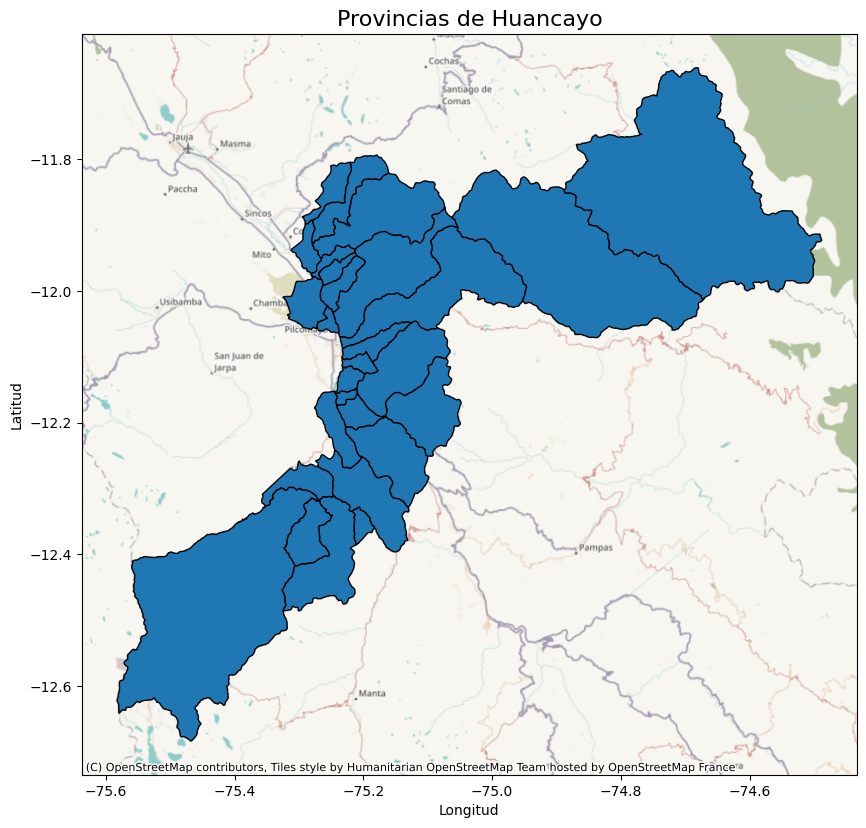

In [ ]:
ax = limiteshuancayo.plot(figsize=(10,10), edgecolor='k')
ctx.add_basemap(ax=ax, crs=limiteshuancayo.crs)
ax.set_title("Provincias de Huancayo", fontsize=16)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.show()

In [ ]:
limiteshuancayo.total_bounds

array([-75.58283986, -12.68371573, -74.48783436, -11.6607371 ])

In [ ]:
from shapely.geometry import Polygon
# Define las coordenadas del bounding box
min_lon, min_lat, max_lon, max_lat = limiteshuancayo.total_bounds

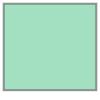

In [ ]:
polygon = Polygon([(min_lon, min_lat), (min_lon, max_lat), (max_lon, max_lat), (max_lon, min_lat)])
polygon

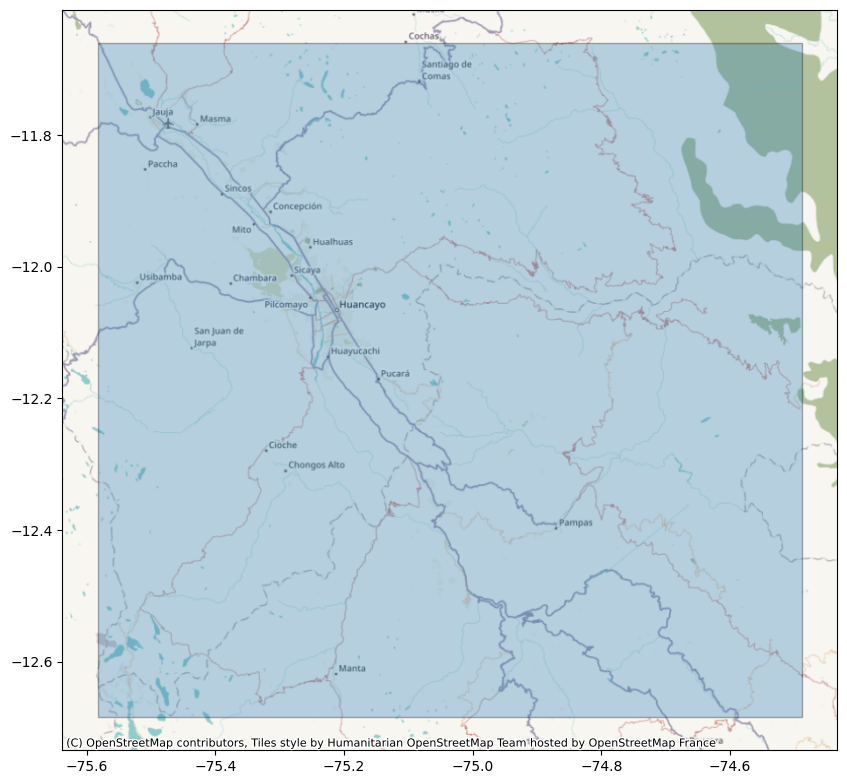

In [ ]:
# Crea un GeoDataFrame a partir del polígono
area_interes = gpd.GeoDataFrame(index=[0], geometry=[polygon], crs="EPSG:4326")

# Visualiza el GeoDataFrame
ax2 = area_interes.plot(alpha=0.3, figsize=(10,10), edgecolor='k')
ctx.add_basemap(ax=ax2, crs=limiteshuancayo.crs)

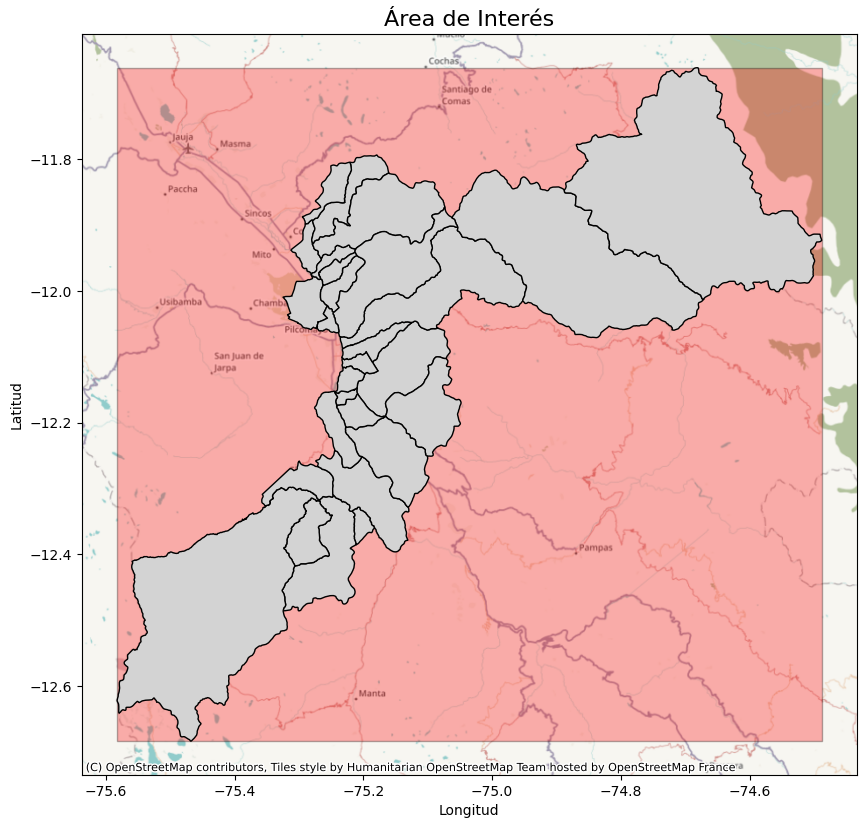

In [ ]:
fig, ax3 = plt.subplots(figsize=(10, 10))
limiteshuancayo.plot(ax=ax3, color='lightgrey', edgecolor='black', zorder=2)
area_interes.plot(ax=ax3, color='red', edgecolor='black', alpha=0.3, zorder=1)
ctx.add_basemap(ax=ax3, crs=area_interes.crs)
ax3.set_title("Área de Interés", fontsize=16)
ax3.set_xlabel("Longitud")
ax3.set_ylabel("Latitud")
plt.show()


In [ ]:
# Resumen Fase 1
#poblacion_limpia  28 distritos
#salud_gdf  382 establecimientos
#limiteshuancayo  28 polígonos
#Todos los datasets están limpios, estandarizados
#y listos para el análisis espacial.

## Fase 2: Adquisición y enriquecimiento de datos

En esta fase se integraron datos complementarios obtenidos desde OpenStreetMap mediante el uso de la API Overpass. Estos datos incluyen establecimientos de salud adicionales como clínicas, hospitales y farmacias.

Posteriormente, la información fue procesada y convertida en un GeoDataFrame, lo que permitió integrarla con los datos oficiales y enriquecer el análisis espacial.

In [ ]:
area_interes.total_bounds

array([-75.58283986, -12.68371573, -74.48783436, -11.6607371 ])

In [ ]:
bbox = area_interes.total_bounds
print(f"sur  : {bbox[1]}")
print(f"oeste: {bbox[0]}")
print(f"norte: {bbox[3]}")
print(f"este : {bbox[2]}")

sur  : -12.68371572999996
oeste: -75.58283985999998
norte: -11.660737103999963
este : -74.48783435899998


In [ ]:
#Funcion para la API
import requests

def obtener_osm(bbox, amenity='clinic'):
    url = 'http://overpass-api.de/api/interpreter'
    query = f'[out:json];node["amenity"="{amenity}"]({bbox[1]},{bbox[0]},{bbox[3]},{bbox[2]});out;'
    response = requests.get(url, params={'data': query})
    return response.json()

print("✅ Función definida")


✅ Función definida


In [ ]:
# llamamos para las 3 principales establecimientos
import time

data_hospitales = obtener_osm(bbox, amenity='hospital')
print(f"Hospitales: {len(data_hospitales['elements'])}")
time.sleep(10)

data_farmacias = obtener_osm(bbox, amenity='pharmacy')
print(f"Farmacias: {len(data_farmacias['elements'])}")
time.sleep(40)

data_clinicas = obtener_osm(bbox, amenity='clinic')
print(f"Clinicas: {len(data_clinicas['elements'])}")
time.sleep(60)

Hospitales: 8
Farmacias: 189
Clinicas: 79


In [ ]:
# Extraer y unir los 3 tipos de establecimientos
osm_lista = []

for data, tipo in [(data_hospitales, 'hospital'),
                   (data_farmacias, 'pharmacy'),
                   (data_clinicas, 'clinic')]:
    for element in data['elements']:
        if element['type'] == 'node':
            osm_lista.append({
                'nombre'   : element.get('tags', {}).get('name', 'Sin nombre'),
                'amenity'  : tipo,
                'latitud'  : element['lat'],
                'longitud' : element['lon']
            })

In [ ]:
# Convertir los resultados a un  DataFrame
osm_df = pd.DataFrame(osm_lista)
print(f"Total establecimientos OSM: {len(osm_df)}")
display(osm_df.head(5))

Total establecimientos OSM: 276


,nombre,amenity,latitud,longitud
0,Posta de Yauyos,hospital,-11.780766,-75.499898
1,Mini Hospital MINSA,hospital,-11.921579,-75.311580
2,Hospital,hospital,-12.063551,-75.220782
3,Posta Médica de Ocopilla,hospital,-12.069947,-75.196391
4,Gobierno Regional Junín,hospital,-12.070095,-75.208892


In [ ]:
# Convertir a GeoDataFrame
geometry = [Point(xy) for xy in zip(osm_df['longitud'], osm_df['latitud'])]
osm_gdf = gpd.GeoDataFrame(osm_df, geometry=geometry, crs="EPSG:4326")

print(f"Tipo    : {type(osm_gdf)}")
print(f"CRS     : {osm_gdf.crs}")
print(f"Filas   : {len(osm_gdf)}")
print(f"Geometría: {osm_gdf.geom_type.unique()}")
display(osm_gdf.head(3))

Tipo    : <class 'geopandas.geodataframe.GeoDataFrame'>
CRS     : EPSG:4326
Filas   : 276
Geometría: ['Point']


,nombre,amenity,latitud,longitud,geometry
0,Posta de Yauyos,hospital,-11.780766,-75.499898,POINT (-75.4999 -11.78077)
1,Mini Hospital MINSA,hospital,-11.921579,-75.311580,POINT (-75.31158 -11.92158)
2,Hospital,hospital,-12.063551,-75.220782,POINT (-75.22078 -12.06355)


In [ ]:
# Unir datos MINSA + OSM en un solo GeoDataFrame
salud_gdf['fuente'] = 'MINSA'
osm_gdf['fuente'] = 'OSM'

# Unir los dos GeoDataFrames
establecimientos = pd.concat([
    salud_gdf[['NOMBRE', 'DISTRITO', 'CATEGORIA', 'geometry', 'fuente']],
    osm_gdf[['nombre', 'amenity', 'geometry', 'fuente']].rename(
        columns={'nombre': 'NOMBRE', 'amenity': 'CATEGORIA'}
    )
], ignore_index=True)

establecimientos = gpd.GeoDataFrame(establecimientos, geometry='geometry', crs='EPSG:4326')

print(f"Total consolidado: {len(establecimientos)}")
print(f"\nPor fuente:")
print(establecimientos['fuente'].value_counts())

Total consolidado: 658

Por fuente:
fuente
MINSA    382
OSM      276
Name: count, dtype: int64


In [ ]:
import numpy as np # Necesario para np.inf

establecimientos['latitude'] = establecimientos.geometry.y
establecimientos['quadrant'] = pd.cut(
    establecimientos['latitude'],
    bins=[-np.inf, -12.45, -12.2, -11.95, np.inf], # Bins ajustados para el rango de latitud de Huancayo
    labels=['Extremo Sur', 'Sur', 'Centro', 'Norte'] # Etiquetas corregidas
)
print(establecimientos["quadrant"].value_counts())
establecimientos.tail()

quadrant
Centro         566
Norte           53
Sur             25
Extremo Sur     14
Name: count, dtype: int64


,NOMBRE,DISTRITO,CATEGORIA,geometry,fuente,latitude,quadrant
653,Sin nombre,NaN,clinic,POINT (-74.54396 -12.15139),OSM,-12.151394,Centro
654,Policlínico Metropolitano Huancayo,NaN,clinic,POINT (-75.22731 -12.0528),OSM,-12.052801,Centro
655,"Posta De Salud: Santiago de Pichus, Pichos",NaN,clinic,POINT (-74.93896 -12.23643),OSM,-12.236434,Sur
656,Policlinico Jauja,NaN,clinic,POINT (-75.5003 -11.76731),OSM,-11.767311,Norte
657,Puesto de Salud Pichiu,NaN,clinic,POINT (-74.63534 -12.3424),OSM,-12.342404,Sur


In [ ]:
geodataFrames = [establecimientos, area_interes, salud_gdf, osm_gdf ]

for i in geodataFrames:
  print(i.crs)

EPSG:4326
EPSG:4326
EPSG:4326
EPSG:4326


In [ ]:
## Resumen Fase 2 ✅
```
# Función obtener_osm() creada
#3 consultas a Overpass API (hospitales, farmacias, clínicas)
# Datos convertidos a GeoDataFrame
# Unidos con datos MINSA en un solo dataset
# 658 establecimientos listos para el análisis

## Fase 3: Análisis espacial

En esta fase se realizaron operaciones de análisis geoespacial para evaluar la accesibilidad a los servicios de salud. Se aplicaron técnicas como la generación de buffers alrededor de los establecimientos, la unión espacial (spatial join) para asignar establecimientos a distritos, y el cálculo de indicadores como el número de establecimientos por cada 10,000 habitantes.

Asimismo, se identificaron las zonas sin cobertura mediante la diferencia entre el área total de la provincia y las áreas cubiertas por los buffers, lo que permitió evidenciar las brechas en el acceso a los servicios de salud.

In [ ]:
# Reproyectar a UTM zona 18S (sistema métrico para Perú)
establecimientos_utm = establecimientos.to_crs('EPSG:32718')
limiteshuancayo_utm  = limiteshuancayo.to_crs('EPSG:32718')

print(f"CRS establecimientos: {establecimientos_utm.crs}")
print(f"CRS distritos       : {limiteshuancayo_utm.crs}")

CRS establecimientos: EPSG:32718
CRS distritos       : EPSG:32718


In [ ]:
# Crear buffers de 1000 metros alrededor de cada establecimiento
buffers = establecimientos_utm.copy()
buffers['geometry'] = establecimientos_utm.buffer(1000)

print(f"Buffers creados: {len(buffers)}")
print(f"Tipo geometría : {buffers.geom_type.unique()}")

Buffers creados: 658
Tipo geometría : ['Polygon']


In [ ]:
print(join.columns.tolist())

In [ ]:
# Spatial Join: cruzar establecimientos con distritos
join = gpd.sjoin(
    establecimientos_utm,
    limiteshuancayo_utm[['DISTRITO', 'geometry']],
    how='left',
    predicate='within'
)

# Renonbrando DISTRITO
join = join.rename(columns={'DISTRITO_right': 'DISTRITO'})

print(f"Total después del join: {len(join)}")
print(f"\nEstablecimientos por distrito:")
print(join['DISTRITO'].value_counts().head())

Total después del join: 658

Establecimientos por distrito:
DISTRITO
HUANCAYO                     301
EL TAMBO                     135
CHILCA                        61
SANTO DOMINGO DE ACOBAMBA     12
PARIAHUANCA                   10
Name: count, dtype: int64


In [ ]:
# Ahora calculamos cuántos establecimientos tiene cada distrito y lo unimos con la población
#Contar establecimientos por distrito
conteo = join.groupby('DISTRITO')['NOMBRE'].count().reset_index()
conteo.columns = ['distrito', 'num_establecimientos']

print(f"Distritos con establecimientos: {len(conteo)}")
display(conteo.head(5))

Distritos con establecimientos: 28


,distrito,num_establecimientos
0,CARHUACALLANGA,1
1,CHACAPAMPA,2
2,CHICCHE,3
3,CHILCA,61
4,CHONGOS ALTO,2


In [ ]:
# Unir conteo de establecimientos con población
metricas = conteo.merge(poblacion_limpia, on='distrito', how='left')

print(f"Filas: {len(metricas)}")
display(metricas.head(5))

Filas: 28


,distrito,num_establecimientos,ubigeo,habitantes
0,CARHUACALLANGA,1,120104,468
1,CHACAPAMPA,2,120105,941
2,CHICCHE,3,120106,687
3,CHILCA,61,120107,100252
4,CHONGOS ALTO,2,120108,1523


Índice = establecimientos / habitantes x 10,000


*  Índice alto  →  pocos habitantes por establecimiento  →  mejor acceso
*  Índice bajo  →  muchos habitantes por establecimiento →  peor acceso



In [ ]:
# Calcular establecimientos por cada 10,000 habitantes
metricas['establecimientos_x_10mil'] = (
    metricas['num_establecimientos'] / metricas['habitantes'] * 10000
).round(2)

display(metricas.head(5))

,distrito,num_establecimientos,ubigeo,habitantes,establecimientos_x_10mil
0,CARHUACALLANGA,1,120104,468,21.37
1,CHACAPAMPA,2,120105,941,21.25
2,CHICCHE,3,120106,687,43.67
3,CHILCA,61,120107,100252,6.08
4,CHONGOS ALTO,2,120108,1523,13.13


In [ ]:
#Ahora ordenamos para ver los distritos con menor y mayor cobertura:
metricas = metricas.sort_values('establecimientos_x_10mil')
print("Distritos con MENOR cobertura:")
display(metricas.head(5))

Distritos con MENOR cobertura:


,distrito,num_establecimientos,ubigeo,habitantes,establecimientos_x_10mil
26,SICAYA,3,120134,22244,1.35
23,SANO,1,120132,6412,1.56
17,PILCOMAYO,4,120125,24039,1.66
10,HUALHUAS,1,120117,6006,1.67
22,SAN JERONIMO DE TUNAN,3,120130,13031,2.30


In [ ]:
print("Distritos con MAYOR cobertura:")
display(metricas.tail(5))

Distritos con MAYOR cobertura:


,distrito,num_establecimientos,ubigeo,habitantes,establecimientos_x_10mil
0,CARHUACALLANGA,1,120104,468,21.37
13,HUASICANCHA,2,120120,840,23.81
12,HUANCAYO,301,120101,124294,24.22
7,CULLHUAS,4,120113,1308,30.58
2,CHICCHE,3,120106,687,43.67


In [ ]:
#Ahora unimos las métricas con el shapefile para poder hacer mapas:

In [ ]:
# Unir métricas con shapefile
limiteshuancayo_utm = limiteshuancayo_utm.merge(
    metricas[['distrito', 'num_establecimientos', 'establecimientos_x_10mil']],
    left_on='DISTRITO',
    right_on='distrito',
    how='left'
)

print(f"Columnas nuevas agregadas:")
print(limiteshuancayo_utm[['DISTRITO','num_establecimientos','establecimientos_x_10mil']].head(5))

Columnas nuevas agregadas:
                DISTRITO  num_establecimientos  establecimientos_x_10mil
0             SAPALLANGA                     7                      2.76
1                 PUCARA                     5                     10.29
2                HUANCAN                     7                      2.33
3               HUANCAYO                   301                     24.22
4  SAN JERONIMO DE TUNAN                     3                      2.30


In [ ]:
# Unir todos los buffers en una sola zona de cobertura
cobertura_total = buffers.union_all()

# Convertir limiteshuancayo a la misma proyección
area_distritos = limiteshuancayo_utm.union_all()

# Calcular zona SIN cobertura
sin_cobertura = area_distritos.difference(cobertura_total)

# Convertir a GeoDataFrame
sin_cobertura_gdf = gpd.GeoDataFrame(
    geometry=[sin_cobertura],
    crs='EPSG:32718'
)

# Calcular porcentaje sin cobertura
area_total = area_distritos.area / 1_000_000
area_sin = sin_cobertura.area / 1_000_000

print(f"Área total Huancayo    : {area_total:.2f} km²")
print(f"Área sin cobertura     : {area_sin:.2f} km²")
print(f"Porcentaje sin cobertura: {area_sin/area_total*100:.1f}%")

Área total Huancayo    : 3733.64 km²
Área sin cobertura     : 3452.88 km²
Porcentaje sin cobertura: 92.5%


## Fase 4: Visualización de resultados

En esta fase se generaron diversas visualizaciones para interpretar los resultados del análisis espacial. Se elaboraron mapas estáticos utilizando GeoPandas y Matplotlib, incluyendo un mapa coroplético del indicador de establecimientos por cada 10,000 habitantes.

Además, se construyeron gráficos estadísticos con Seaborn para analizar la distribución de la cobertura entre distritos. Finalmente, se desarrolló un mapa interactivo con Folium, el cual permite explorar la ubicación de los establecimientos de salud y los límites distritales de manera dinámica.

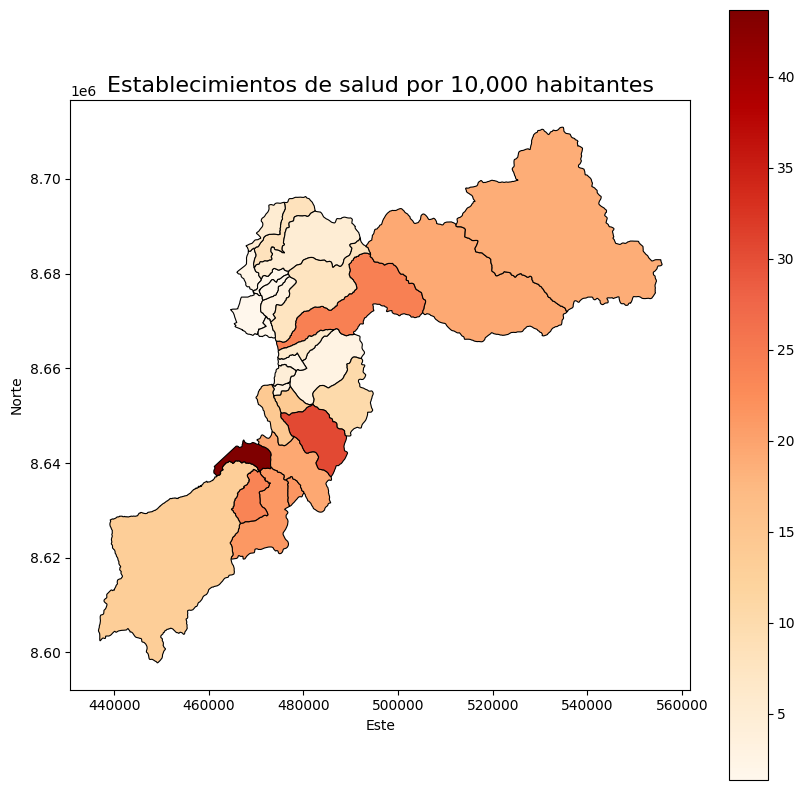

In [ ]:
fig, ax3 = plt.subplots(figsize=(10, 10))

limiteshuancayo_utm.plot(
    column='establecimientos_x_10mil',
    ax=ax3,
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.8,
    legend=True,
    zorder=2
)

ax3.set_title("Establecimientos de salud por 10,000 habitantes", fontsize=16)
ax3.set_xlabel("Este")
ax3.set_ylabel("Norte")
plt.show()

In [ ]:
limites_vis = limiteshuancayo_utm.to_crs(epsg=3857)
buffers_vis = buffers.to_crs(epsg=3857)
sin_cobertura_vis = sin_cobertura_gdf.to_crs(epsg=3857)
establecimientos_vis = establecimientos_utm.to_crs(epsg=3857)

print(limites_vis.crs)

EPSG:3857


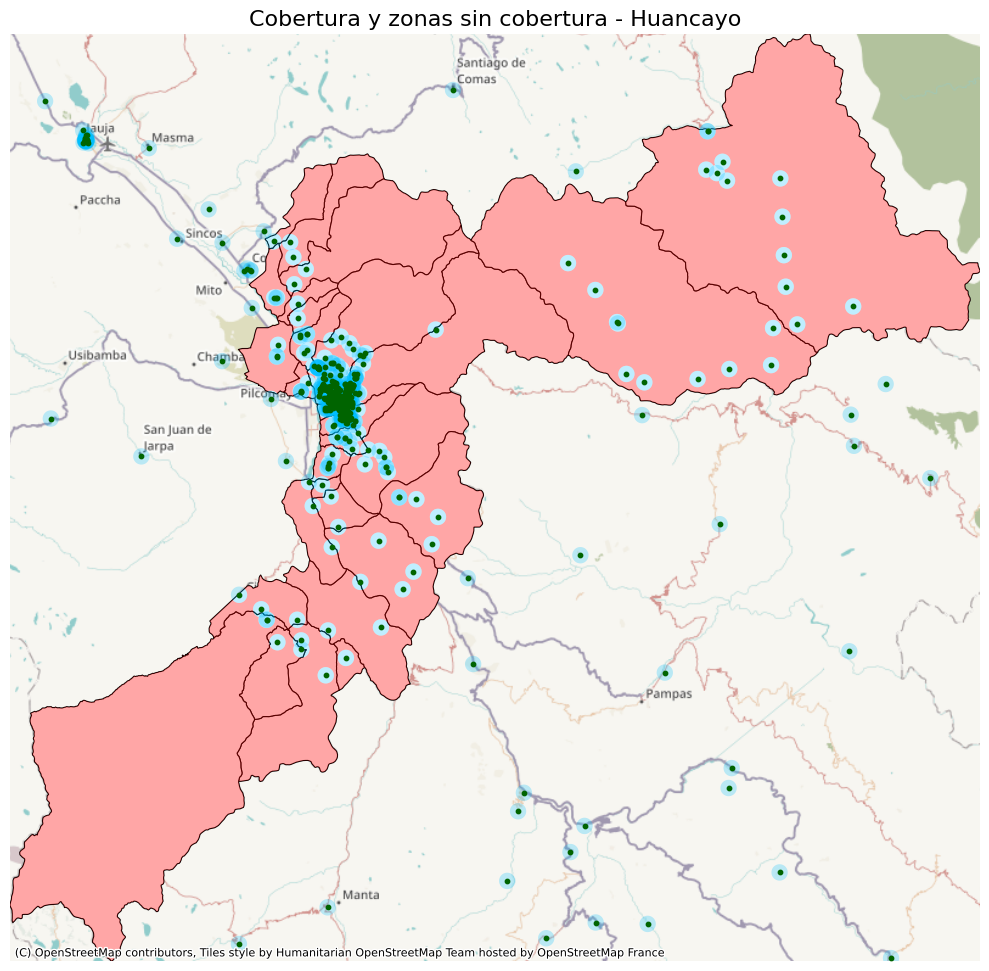

In [ ]:
fig, ax3 = plt.subplots(figsize=(10, 10))

limites_vis.plot(ax=ax3, color='white', edgecolor='black', linewidth=0.8, zorder=1)
sin_cobertura_vis.plot(ax=ax3, color='red', alpha=0.35, edgecolor='none', zorder=2)
buffers_vis.plot(ax=ax3, color='deepskyblue', alpha=0.25, edgecolor='none', zorder=3)
establecimientos_vis.plot(ax=ax3, color='darkgreen', markersize=10, zorder=4)

# recortar vista al área de Huancayo
xmin, ymin, xmax, ymax = limites_vis.total_bounds
ax3.set_xlim(xmin, xmax)
ax3.set_ylim(ymin, ymax)

ctx.add_basemap(ax3, crs=limites_vis.crs)

ax3.set_title("Cobertura y zonas sin cobertura - Huancayo", fontsize=16)
ax3.set_axis_off()

plt.tight_layout()
plt.show()

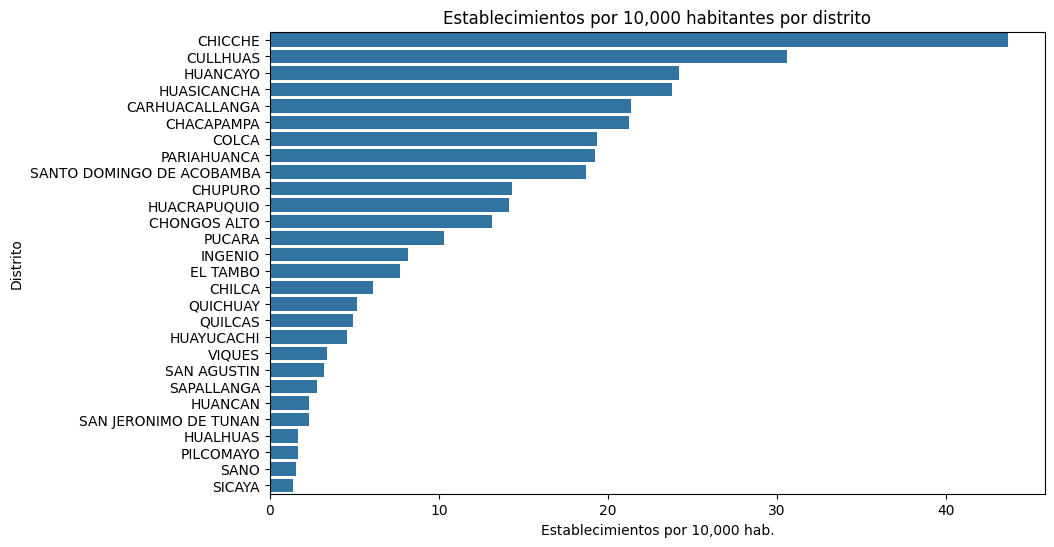

In [ ]:
import seaborn as sns


plt.figure(figsize=(10,6))

sns.barplot(
    data=metricas.sort_values('establecimientos_x_10mil', ascending=False),
    x='establecimientos_x_10mil',
    y='distrito'
)

plt.title('Establecimientos por 10,000 habitantes por distrito')
plt.xlabel('Establecimientos por 10,000 hab.')
plt.ylabel('Distrito')

plt.show()

#CHICCHE → muy alto → buena cobertura
#SICAYA → muy bajo → mala cobertura

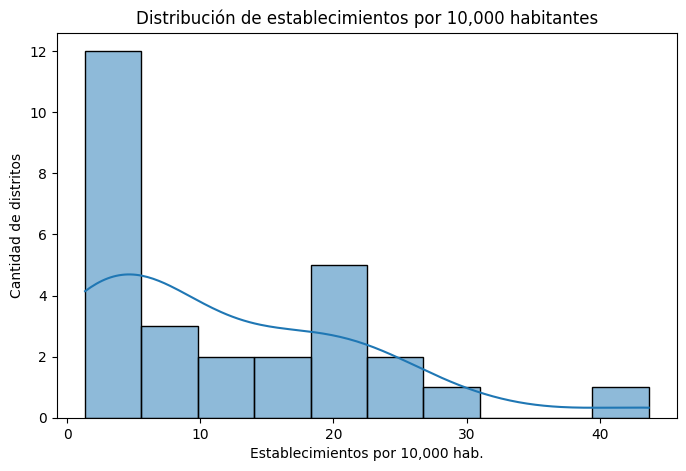

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    metricas['establecimientos_x_10mil'],
    bins=10,
    kde=True
)

plt.title('Distribución de establecimientos por 10,000 habitantes')
plt.xlabel('Establecimientos por 10,000 hab.')
plt.ylabel('Cantidad de distritos')

plt.show()

La distribución muestra que la mayoría de distritos presenta valores bajos de establecimientos por 10,000 habitantes, mientras que pocos distritos alcanzan niveles altos de cobertura.

In [ ]:
import folium

# pasar a WGS84 para Folium
limites_folium = limiteshuancayo_utm.to_crs(epsg=4326)
establecimientos_folium = establecimientos_utm.to_crs(epsg=4326)

# centro del mapa
centro = [
    limites_folium.geometry.centroid.y.mean(),
    limites_folium.geometry.centroid.x.mean()
]

m = folium.Map(location=centro, zoom_start=10)

# capa de distritos
folium.GeoJson(
    limites_folium,
    name="Distritos"
).add_to(m)

# puntos de establecimientos
for _, row in establecimientos_folium.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3,
        color="green",
        fill=True,
        fill_opacity=0.7,
        popup=str(row.get("NOMBRE", "Sin nombre"))
    ).add_to(m)

folium.LayerControl().add_to(m)

m

/tmp/ipykernel_14094/2037328040.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  limites_folium.geometry.centroid.y.mean(),
/tmp/ipykernel_14094/2037328040.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  limites_folium.geometry.centroid.x.mean()


In [ ]:
m.save("mapa_huancayo.html")


**COMCLUSIONES**

El análisis espacial de los servicios de salud en la provincia de Huancayo evidencia una distribución desigual de la cobertura sanitaria entre los distritos. A partir del indicador de establecimientos por cada 10,000 habitantes, se observa que algunos distritos como Chicche presentan valores elevados, mientras que otros como Sicaya y Sano muestran niveles significativamente bajos.

Asimismo, los resultados del análisis de buffers indican que existe una alta proporción del territorio sin cobertura efectiva, alcanzando aproximadamente el 92.5% del área total. Esto sugiere que, a pesar de la presencia de establecimientos, gran parte del territorio no se encuentra dentro de un radio de acceso cercano (1 km), lo que puede representar dificultades en el acceso físico a los servicios de salud.

Por otro lado, la distribución de los establecimientos muestra una clara concentración en zonas urbanas centrales, especialmente en el área de Huancayo, mientras que las zonas periféricas y rurales presentan menor densidad de servicios. Este patrón refleja posibles brechas territoriales en la provisión de infraestructura sanitaria.

En conjunto, estos hallazgos evidencian la necesidad de fortalecer la planificación territorial de los servicios de salud, priorizando los distritos con menor cobertura y las zonas alejadas del centro urbano, con el fin de mejorar el acceso equitativo de la población a servicios básicos de salud.
